https://www.kaggle.com/datasets/adilshamim8/daily-food-and-nutrition-dataset

In [4]:
!pip install s3fs -q

In [7]:
import sagemaker
print(sagemaker.get_execution_role())

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
arn:aws:iam::435306060076:role/LabRole


In [10]:
import boto3, pandas as pd, joblib
from io import StringIO
 
s3 = boto3.client("s3", region_name="us-east-1")  # change region if needed

obj = s3.get_object(Bucket="food-waste-project", Key="cleaned_nutrition_engineered.csv
")
df = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")), quotechar='"', on_bad_lines='skip')

print("Shape:", df.shape)
print(df.head())

print("Shape:", df.shape)
print(df.head())
print(df['Meal_Type'].value_counts())

╭──────────────────────────────────────────────────────────────────────────────────────────────────╮
│ obj = s3.get_object(Bucket="food-waste-project", Key="cleaned_nutrition_engineered.csv           │
│                                                      ▲                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
SyntaxError: unterminated string literal (detected at line 6)

In [9]:
s3 = boto3.client("s3", region_name="us-east-1")

response = s3.list_objects_v2(Bucket="food-waste-project")

for obj in response.get("Contents", []):
    print(obj["Key"])


cleaned_nutrition.csv
cleaned_nutrition_engineered.csv
instacart_cleaned.csv


In [ ]:
import re

# Create a new column called Description
df["Description"] = df["Food_Item"].str.extract(r"\((.*?)\)")

# Remove the parentheses content from Food_Item to clean the name
df["Food_Item_Clean"] = df["Food_Item"].str.replace(r"\s*\(.*?\)", "", regex=True)

df[["Food_Item", "Food_Item_Clean", "Description"]].head(10)

In [2]:
# Keep only the three main meal types
main_meals = ["Breakfast", "Lunch", "Dinner"]

df_main = df[df["Meal_Type"].isin(main_meals)].reset_index(drop=True)

print("New shape:", df_main.shape)
print(df_main["Meal_Type"].value_counts())
df_main.head()

NameError: name 'df' is not defined

In [21]:
# Select the numeric nutrition columns
numeric_features = [
    "Calories (kcal)",
    "Protein (g)",
    "Carbohydrates (g)",
    "Fat (g)",
    "Fiber (g)",
    "Sugars (g)",
    "Sodium (mg)",
    "Cholesterol (mg)",
    "Water_Intake (ml)"
]

# X = features, y = target
X = df_main[numeric_features]
y = df_main["Meal_Type"]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (465, 9)
y distribution:
Meal_Type
Dinner       224
Lunch        148
Breakfast     93
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train distribution:")
print(y_train.value_counts())
print("Test distribution:")
print(y_test.value_counts())

Train shape: (372, 9)
Test shape: (93, 9)
Train distribution:
Meal_Type
Dinner       179
Lunch        119
Breakfast     74
Name: count, dtype: int64
Test distribution:
Meal_Type
Dinner       45
Lunch        29
Breakfast    19
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (372, 9)
Scaled test shape: (93, 9)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"   # helps with Breakfast being the smallest class
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


Classification Report:
              precision    recall  f1-score   support

   Breakfast       0.70      0.37      0.48        19
      Dinner       0.61      0.78      0.69        45
       Lunch       0.50      0.45      0.47        29

    accuracy                           0.59        93
   macro avg       0.60      0.53      0.55        93
weighted avg       0.60      0.59      0.58        93



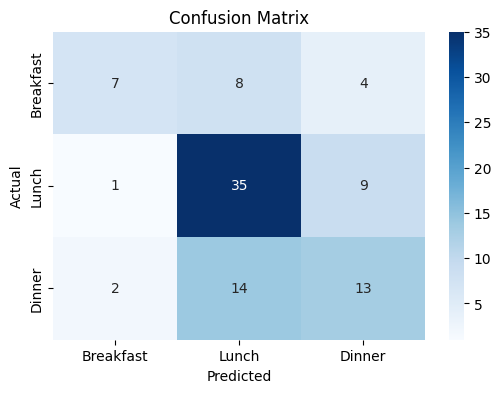

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test_scaled)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Breakfast", "Lunch", "Dinner"],
    yticklabels=["Breakfast", "Lunch", "Dinner"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

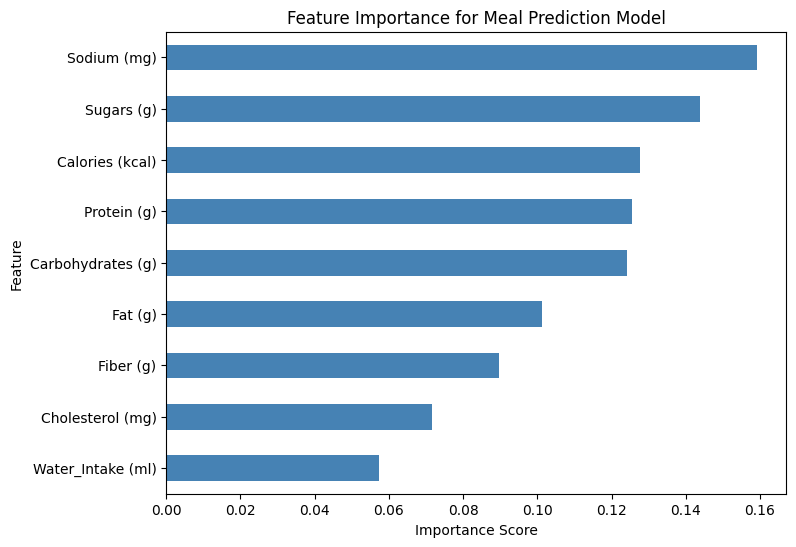

,0
Sodium (mg),0.159115
Sugars (g),0.143789
Calories (kcal),0.127546
Protein (g),0.125575
Carbohydrates (g),0.124221
Fat (g),0.101323
Fiber (g),0.089576
Cholesterol (mg),0.071635
Water_Intake (ml),0.057220


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained Random Forest
importances = pd.Series(model.feature_importances_, index=numeric_features)

# Sort and plot
plt.figure(figsize=(8,6))
importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance for Meal Prediction Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Print sorted values for clarity
importances.sort_values(ascending=False)

In [27]:
import numpy as np

def predict_meal(calories, protein, carbs, fat, fiber, sugars, sodium, cholesterol, water):
    # Create a single-row DataFrame
    row = pd.DataFrame([[
        calories, protein, carbs, fat, fiber, sugars, sodium, cholesterol, water
    ]], columns=numeric_features)

    # Scale using the same scaler fitted earlier
    row_scaled = scaler.transform(row)

    # Predict class and probabilities
    pred_class = model.predict(row_scaled)[0]
    pred_proba = model.predict_proba(row_scaled)[0]

    # Package probabilities nicely
    proba_dict = dict(zip(model.classes_, np.round(pred_proba, 3)))

    return pred_class, proba_dict

# Example usage:
example_pred, example_probs = predict_meal(
    calories=150,
    protein=5,
    carbs=30,
    fat=3,
    fiber=2,
    sugars=10,
    sodium=120,
    cholesterol=5,
    water=200
)

print("Predicted Meal:", example_pred)
print("Probabilities:", example_probs)

Predicted Meal: Breakfast
Probabilities: {'Breakfast': np.float64(0.843), 'Dinner': np.float64(0.107), 'Lunch': np.float64(0.05)}


In [28]:
# Make a copy so we don't overwrite df_main
df_fe = df_main.copy()

# 1. Protein density (protein per calorie)
df_fe["Protein_Density"] = df_fe["Protein (g)"] / (df_fe["Calories (kcal)"] + 1)

# 2. Sugar density (sugars per calorie)
df_fe["Sugar_Density"] = df_fe["Sugars (g)"] / (df_fe["Calories (kcal)"] + 1)

# 3. Carb-to-fat ratio
df_fe["Carb_Fat_Ratio"] = df_fe["Carbohydrates (g)"] / (df_fe["Fat (g)"] + 1)

# 4. Sodium per calorie
df_fe["Sodium_Density"] = df_fe["Sodium (mg)"] / (df_fe["Calories (kcal)"] + 1)

# 5. Fiber per carb
df_fe["Fiber_Carb_Ratio"] = df_fe["Fiber (g)"] / (df_fe["Carbohydrates (g)"] + 1)

# 6. Cholesterol per calorie
df_fe["Cholesterol_Density"] = df_fe["Cholesterol (mg)"] / (df_fe["Calories (kcal)"] + 1)

# Show the new columns
df_fe.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Description,Food_Item_Clean,Protein_Density,Sugar_Density,Carb_Fat_Ratio,Sodium_Density,Fiber_Carb_Ratio,Cholesterol_Density
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250,2 large,Scrambled Eggs,0.066298,0.005525,0.133333,0.994475,0.000000,2.044199
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0,1 slice,Whole Wheat Toast,0.049383,0.024691,7.000000,1.728395,0.133333,0.000000
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0,black,Coffee,0.050000,0.000000,0.000000,0.833333,0.000000,0.000000
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0,NaN,Banana,0.012264,0.132075,19.285714,0.009434,0.110714,0.000000
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500,NaN,Grilled Chicken Salad,0.085470,0.011396,0.476190,1.139601,0.454545,0.227920


In [29]:
# Original numeric features
base_features = [
    "Calories (kcal)",
    "Protein (g)",
    "Carbohydrates (g)",
    "Fat (g)",
    "Fiber (g)",
    "Sugars (g)",
    "Sodium (mg)",
    "Cholesterol (mg)",
    "Water_Intake (ml)"
]

# Engineered features
engineered_features = [
    "Protein_Density",
    "Sugar_Density",
    "Carb_Fat_Ratio",
    "Sodium_Density",
    "Fiber_Carb_Ratio",
    "Cholesterol_Density"
]

# Combine them
all_features = base_features + engineered_features

X2 = df_fe[all_features]
y2 = df_fe["Meal_Type"]

print("X2 shape:", X2.shape)
print("y2 distribution:")
print(y2.value_counts())

X2 shape: (465, 15)
y2 distribution:
Meal_Type
Dinner       224
Lunch        148
Breakfast     93
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Train:", X2_train.shape, "Test:", X2_test.shape)

Train: (372, 15) Test: (93, 15)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Scaled shapes:", X2_train_scaled.shape, X2_test_scaled.shape)

Scaled shapes: (372, 15) (93, 15)


In [32]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

model2.fit(X2_train_scaled, y2_train)

print("Model 2 trained successfully.")

Model 2 trained successfully.


Classification Report (Engineered Features):
              precision    recall  f1-score   support

   Breakfast       0.73      0.42      0.53        19
      Dinner       0.62      0.71      0.66        45
       Lunch       0.47      0.48      0.47        29

    accuracy                           0.58        93
   macro avg       0.60      0.54      0.56        93
weighted avg       0.59      0.58      0.58        93



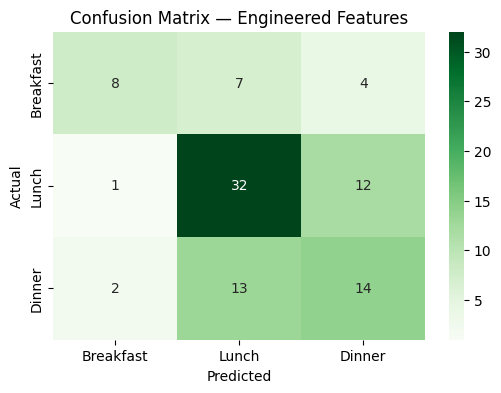

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y2_pred = model2.predict(X2_test_scaled)

print("Classification Report (Engineered Features):")
print(classification_report(y2_test, y2_pred))

cm2 = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Breakfast", "Lunch", "Dinner"],
    yticklabels=["Breakfast", "Lunch", "Dinner"]
)
plt.title("Confusion Matrix — Engineered Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

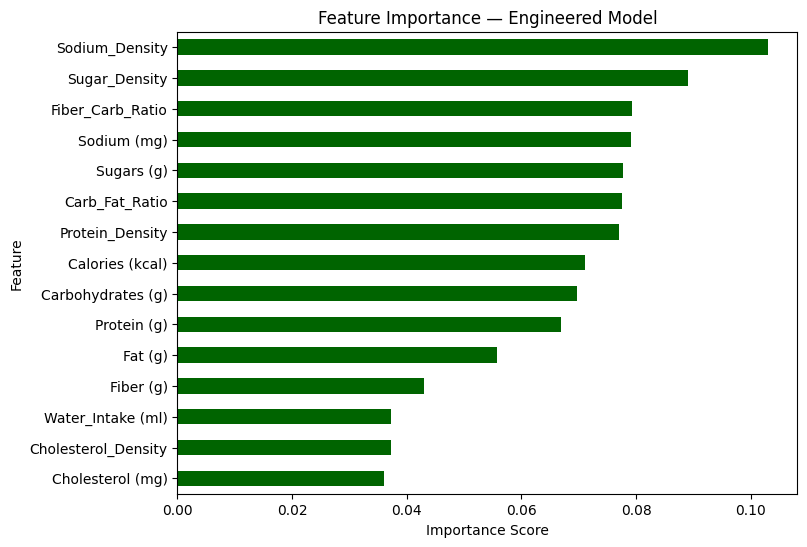

,0
Sodium_Density,0.102992
Sugar_Density,0.089082
Fiber_Carb_Ratio,0.079252
Sodium (mg),0.079116
Sugars (g),0.077686
Carb_Fat_Ratio,0.077574
Protein_Density,0.076976
Calories (kcal),0.071013
Carbohydrates (g),0.069782
Protein (g),0.066990


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from the improved model
importances2 = pd.Series(model2.feature_importances_, index=all_features)

# Plot sorted importances
plt.figure(figsize=(8,6))
importances2.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Feature Importance — Engineered Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Print sorted values for reporting
importances2.sort_values(ascending=False)

In [35]:
# After your df_main cleaning step
df_main.to_csv("cleaned_nutrition.csv", index=False)

In [36]:
# After your df_fe feature engineering step
df_fe.to_csv("cleaned_nutrition_engineered.csv", index=False)